# **RANDOM FOREST**

Valutiamo accuracy e sensitivity di random forest con diversi iperparametri. 

## Preparazione dei dati

---

In [1]:
import numpy as np
# Segnale su cui effettuare Train e Validation
g_0_b = np.loadtxt('data/g_0_signal_b.txt')
g_1_b = np.loadtxt('data/g_1_signal_b.txt')
# Segnale su cui effettuare Test Esterno
g_0_a = np.loadtxt('data/g_0_signal_a.txt')
g_1_a = np.loadtxt('data/g_1_signal_a.txt')

Concatenazione gruppi e vettore dei label:

In [2]:
N0, N1 = g_0_b.shape[0], g_1_b.shape[0]
# concateno g_0 e g_1
signal_b = np.vstack((g_0_b, g_1_b))
signal_a = np.vstack((g_0_a, g_1_a))

# vettore delle risposte
labels = np.concatenate((np.zeros(N0), np.ones(N1))) # uguale per A e B

## Importazioni

---

In [3]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from sklearn.ensemble import RandomForestClassifier as RFC

<b>

## GridSearch

---

In [4]:
rkf = RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42)

# PCA [2 (25%), 7 (50%), 10 (60%), 14 (70%), 19 (80%), 27 (90%), None: tutte le componenti]
N_COMPONENTS_OPTIONS = [2, 7, 10, 14, 19, 27, None]
# ESTIMATOR
N_ESTIMATOR_OPTIONS = [50, 75, 100, 125, 150, 175, 200]

# 1. Definizione Pipeline #
pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", RobustScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    ("reduce_dim", PCA(random_state=42)),
    
    # Step 3: Classificatore BOOTSTRAP SEMPRE TRUE PERCHÉ HO POCHI SAMPLES (44)
    ("classify", RFC(
        random_state=42, 
        bootstrap=True, 
        criterion='gini',
        max_features = 'sqrt',
        max_depth=4,
        min_samples_leaf=1,
        )
    ) 
])

# 2. Definizione griglia dei parametri #
param_grid = {
    
    # Per provare parametri specifici di uno step (PCA)
    "reduce_dim__n_components": N_COMPONENTS_OPTIONS, 
    
    # Per provare parametri del classificatore
    "classify__n_estimators": N_ESTIMATOR_OPTIONS,
    
}

# 3. Configurazione GridSearch #
grid = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=rkf,
    n_jobs=-1, # «Number of jobs to run in parallel. -1 means using all processors»
    scoring={
        'score': 'accuracy',
        'sensitivity': 'recall'  # recall = sensitivity
    },
    refit='score', # «For multiple metric evaluation, needs to be a str denoting the
    # scorer to use to find the best parameters for refitting the estimator at the end»
    return_train_score=False
)

# 4. Training e Validation (su Segnale B) #
grid.fit(signal_b, labels)

# 5. Risultati #
print(f"La miglior configurazione: {grid.best_params_}")
print(f"Fornisce accuracy in validation: {grid.best_score_:.4f}")

# 6. Test su segnale A #
accuracy_finale = grid.score(signal_a, labels)
print(f"Risultato sul set indipendente (Segnale A): {accuracy_finale:.4f}")

La miglior configurazione: {'classify__n_estimators': 175, 'reduce_dim__n_components': 7}
Fornisce accuracy in validation: 0.6612
Risultato sul set indipendente (Segnale A): 0.4318


### heatmaps **accuracy** e **sensitivity** PCA v n_estimators

In [5]:
import pandas as pd
results_df = pd.DataFrame(grid.cv_results_)

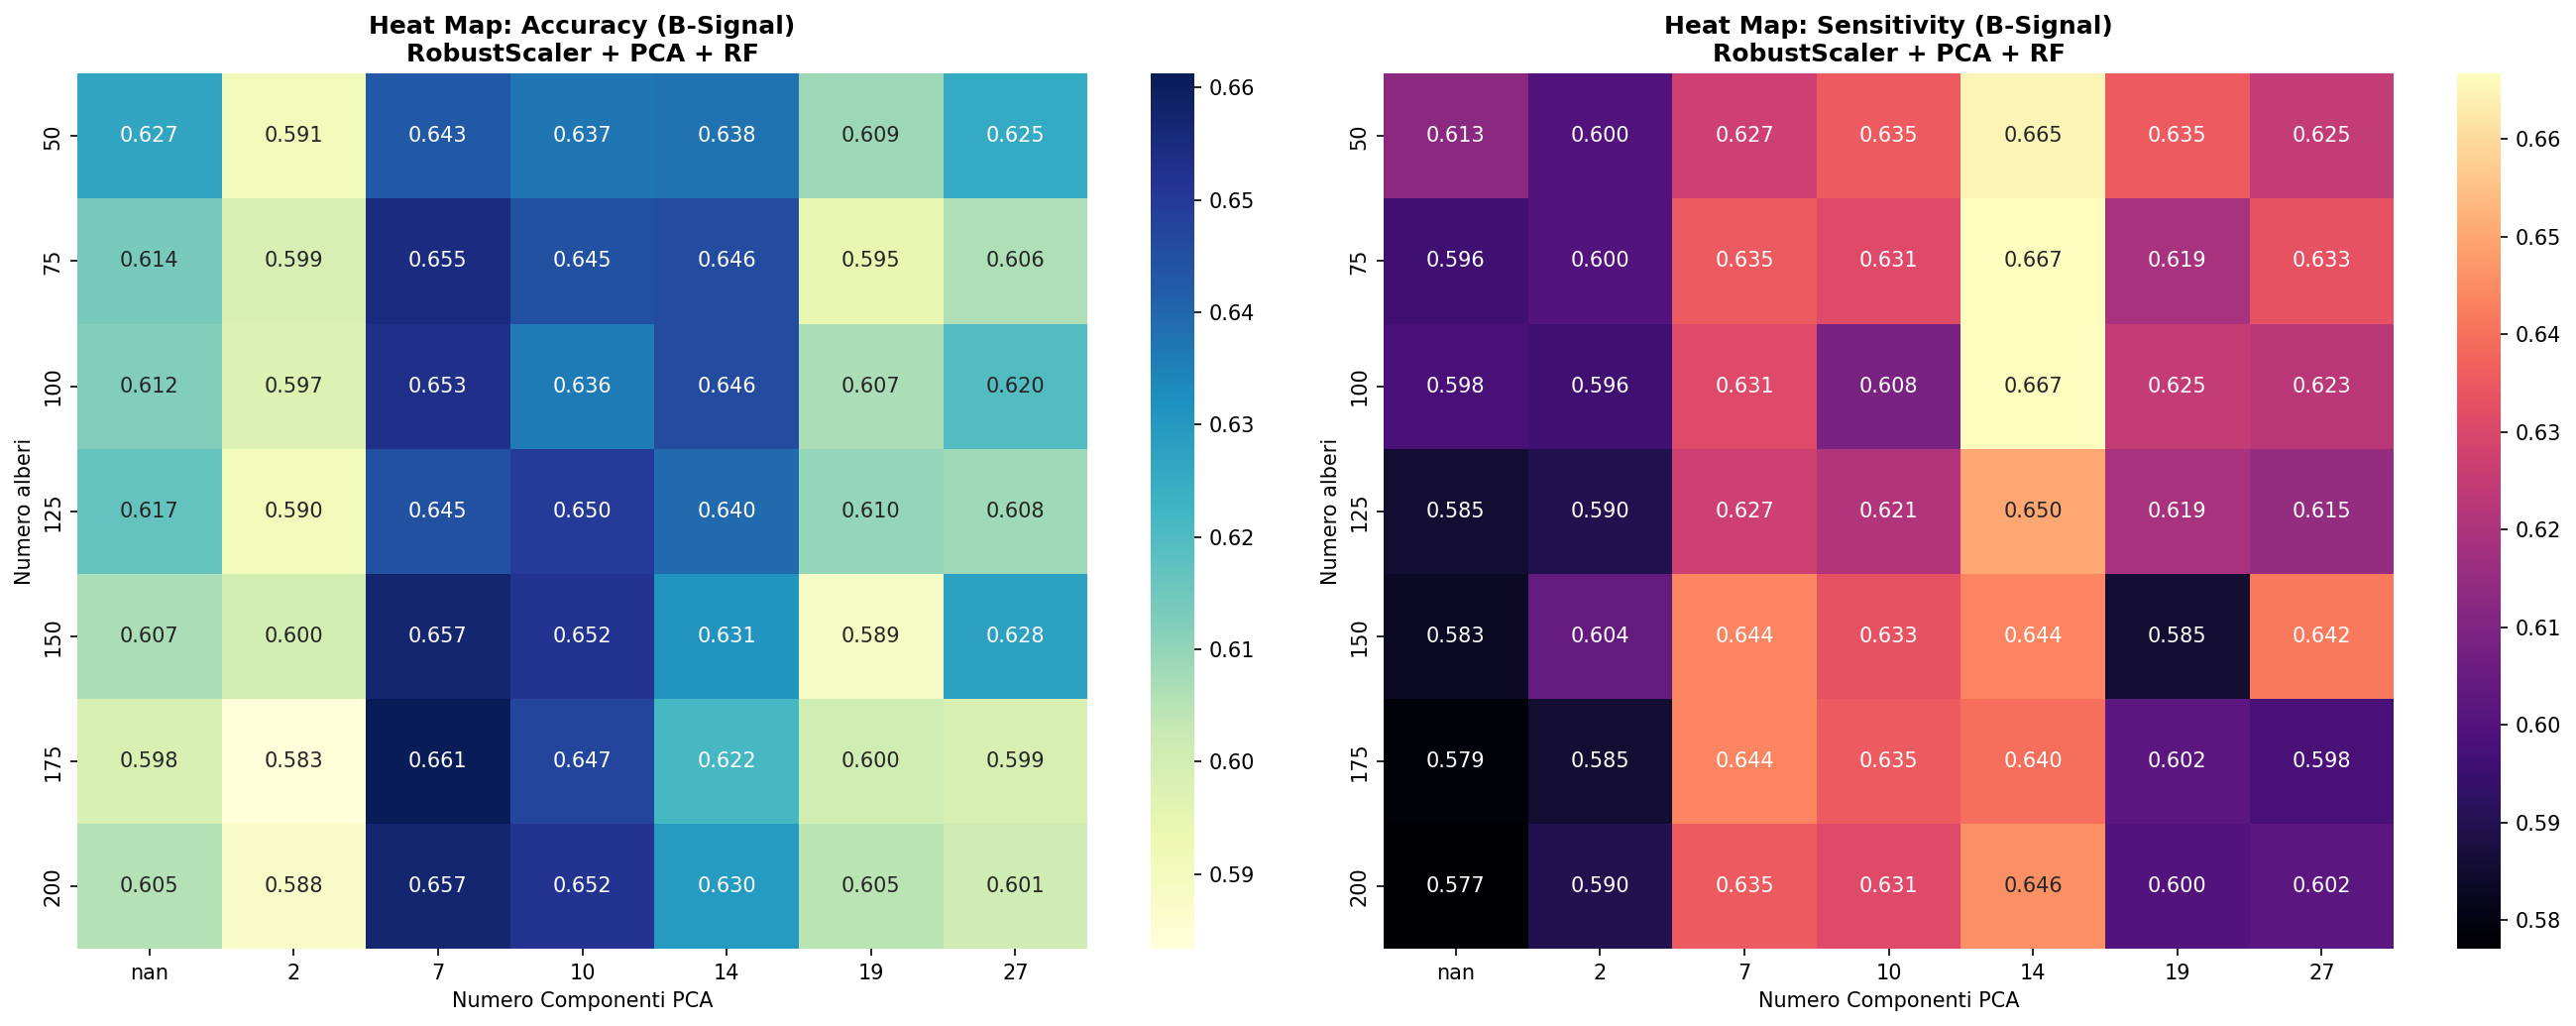

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparazione dei dati: Pivot delle tabelle
# Trasformiamo il DataFrame in matrici (Indice = C, Colonne = n_components)
pivot_acc = results_df.pivot(index='param_classify__n_estimators', 
                                 columns='param_reduce_dim__n_components', 
                                 values='mean_test_score')

pivot_sens = results_df.pivot(index='param_classify__n_estimators', 
                                  columns='param_reduce_dim__n_components', 
                                  values='mean_test_sensitivity')

# 2. Creazione della figura
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)

# --- Heatmap Accuracy ---
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title('Heat Map: Accuracy (B-Signal)\nRobustScaler + PCA + RF', fontweight='bold')
axes[0].set_xlabel('Numero Componenti PCA')
axes[0].set_ylabel('Numero alberi')

# --- Heatmap Sensitivity ---
sns.heatmap(pivot_sens, annot=True, fmt=".3f", cmap="magma", ax=axes[1])
axes[1].set_title('Heat Map: Sensitivity (B-Signal)\nRobustScaler + PCA + RF', fontweight='bold')
axes[1].set_xlabel('Numero Componenti PCA')
axes[1].set_ylabel('Numero alberi')

plt.tight_layout()
plt.show()